In [ ]:
import pandas as pd
import numpy as np
#from sklearn.preprocessing import LabelEncoder

#from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import to_categorical

# for modeling
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

from keras.layers import Dense,SimpleRNN,LSTM,Embedding
from keras.preprocessing import sequence

from sklearn.preprocessing import StandardScaler,LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)
data = pd.read_excel('/content/drive/My Drive/OrginalAQTehran.xlsx')

data.drop('Time',axis=1,inplace=True)
def probThreshold(inpProb):
    if inpProb  <  51:
        return(0)
    if 50<inpProb < 101:
        return(1)
    if 100<inpProb<151:
        return(2)
    if 150<inpProb<201:
        return(3)
    if 200<inpProb<301:
        return(4)
    else:
        return(5)

data['Outcomes']=data['AQI'].apply(probThreshold)
#print(data[1:10])

X=data.iloc[:,:-2].values
y=data.iloc[:,-1].values
scaler=StandardScaler()
X=scaler.fit_transform(X)
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)
X=X.reshape((X.shape[0],1,X.shape[1]))

#X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.15,random_state =123)
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=.15, random_state =12)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.176, random_state=12) #0.176 * 0.85 = 0.15

unique, counts = np.unique(y_train, return_counts=True)
print("TrainSet (class: count) = ", dict(zip(unique, counts)), "TestSize : ", y_train.shape[0])

unique, counts = np.unique(y_test, return_counts=True)
print("TestSet (class: count) =", dict(zip(unique, counts)), "TestSize : ", y_test.shape[0])

unique, counts = np.unique(y_val, return_counts=True)
print("ValSet (class: count) = ", dict(zip(unique, counts)), "ValSize : ", y_val.shape[0])

print(y.shape[0], " = ", (y_train.shape[0] + y_test.shape[0] + y_val.shape[0]))


Mounted at /content/drive
TrainSet (class: count) =  {0: 54, 1: 835, 2: 339, 3: 48, 4: 1, 5: 1} TestSize :  1278
TestSet (class: count) = {0: 12, 1: 185, 2: 70, 3: 7, 5: 1} TestSize :  275
ValSet (class: count) =  {0: 13, 1: 176, 2: 78, 3: 6, 4: 1} ValSize :  274
1827  =  1827


In [ ]:
dummy_y_train = to_categorical(y_train, 6)
print(dummy_y_train)

dummy_y_test = to_categorical(y_test, 6)
print(dummy_y_test)

dummy_y_val = to_categorical(y_val, 6)
print(dummy_y_val)

print(X_train.shape)
print(dummy_y_train.shape)


[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
(1278, 1, 14)
(1278, 6)


In [ ]:
model = Sequential()

import keras
from keras.callbacks import EarlyStopping
es = keras.callbacks.EarlyStopping(monitor='val_loss', #val_accuracy #val_loss
                                   mode='auto',
                                   patience=100,
                                   restore_best_weights=True)
from keras.callbacks import ModelCheckpoint
mcp_save = ModelCheckpoint('/content/drive/My Drive/best_model_RNN.keras', save_best_only=True, monitor='val_loss', mode='auto') #.mdl_wts.hdf5

model.add(LSTM(21,input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'))
model.add(Dense(32, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='RMSprop', metrics=['accuracy'])#adam #loss='sparse_categorical_crossentropy'

model.fit(X_train, dummy_y_train.argmax(axis=1), epochs=2000, batch_size=55, callbacks=[es, mcp_save], validation_data=(X_val, y_val),
                    validation_batch_size = 89, shuffle = True)
#1,278 : 1, 2, 3, 6, 9, 18, 71, 142, 213, 426, 639, 1278
#274 : 1, 2, 137, 274
#fib : 0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181

Epoch 1/2000
24/24 [==============================] - 5s 50ms/step - loss: 3.3776 - accuracy: 0.1142 - val_loss: 3.2845 - val_accuracy: 0.2956
Epoch 2/2000
24/24 [==============================] - 0s 13ms/step - loss: 3.1676 - accuracy: 0.4601 - val_loss: 3.0718 - val_accuracy: 0.4526
Epoch 3/2000
24/24 [==============================] - 0s 14ms/step - loss: 2.9145 - accuracy: 0.5751 - val_loss: 2.8014 - val_accuracy: 0.5584
Epoch 4/2000
24/24 [==============================] - 0s 13ms/step - loss: 2.6026 - accuracy: 0.6346 - val_loss: 2.4840 - val_accuracy: 0.5766
Epoch 5/2000
24/24 [==============================] - 0s 14ms/step - loss: 2.2605 - accuracy: 0.6659 - val_loss: 2.1524 - val_accuracy: 0.6277
Epoch 6/2000
24/24 [==============================] - 0s 15ms/step - loss: 1.9253 - accuracy: 0.6839 - val_loss: 1.8419 - val_accuracy: 0.6460
Epoch 7/2000
24/24 [==============================] - 0s 12ms/step - loss: 1.6290 - accuracy: 0.7081 - val_loss: 1.5688 - val_accuracy: 0.6642

In [ ]:
Predictions=model.predict(X_test).argmax(axis=1)
Accuracy=model.evaluate(X_test, dummy_y_test.argmax(axis=1))[1]
print(f'Test Accuracy:{Accuracy*100:.2f}%')

9/9 [==============================] - 0s 3ms/step - loss: 0.1533 - accuracy: 0.9418
Test Accuracy:94.18%


0.9418181818181818
0.663037323037323
0.6781288981288981
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.97      0.97      0.97       185
           2       0.90      0.94      0.92        70
           3       0.80      0.57      0.67         7
           5       0.00      0.00      0.00         1

    accuracy                           0.94       275
   macro avg       0.70      0.66      0.68       275
weighted avg       0.94      0.94      0.94       275



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


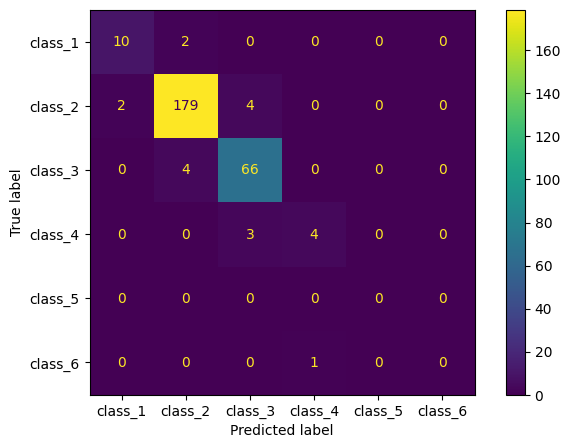

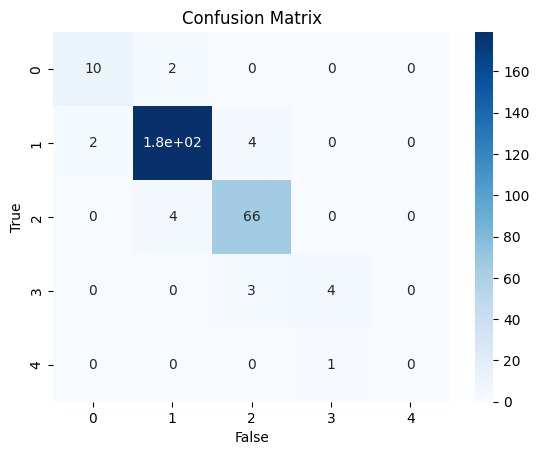

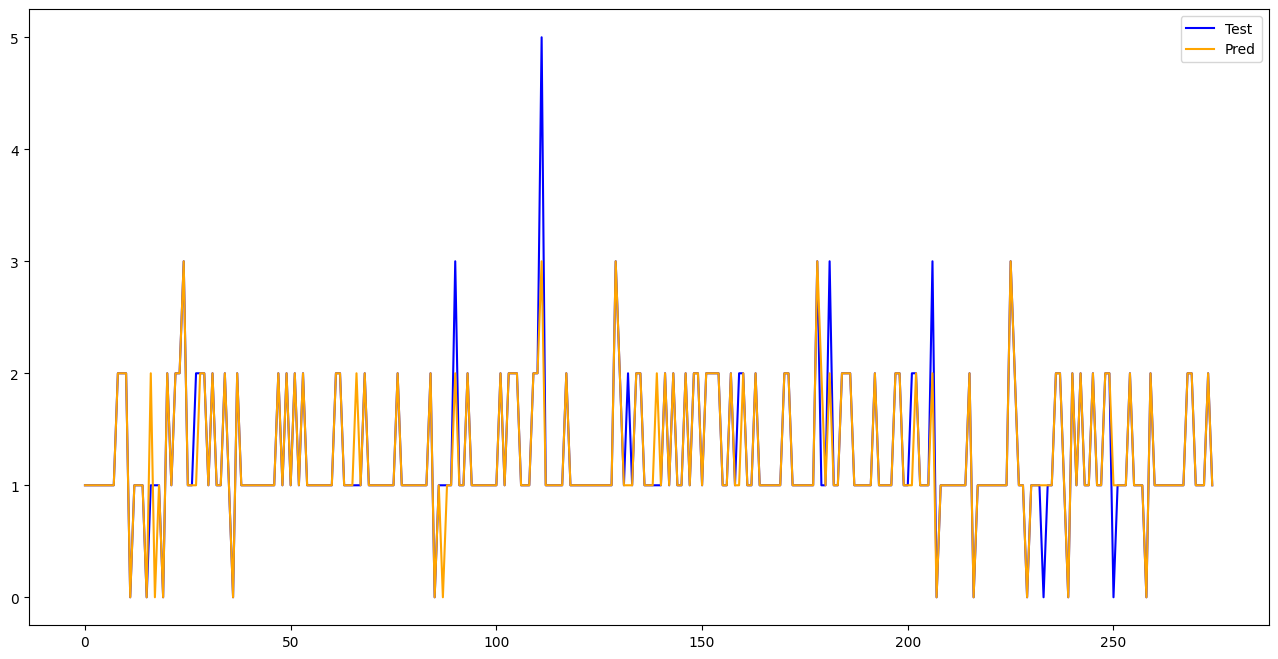

In [ ]:
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
# print(metrics.classification_report(y_test, Predictions))
# print(metrics.confusion_matrix(y_test, Predictions))
# print(metrics.precision_score(y_test, Predictions))
print(accuracy_score(dummy_y_test.argmax(axis=1),Predictions))
print(balanced_accuracy_score(dummy_y_test.argmax(axis=1),Predictions))
print(f1_score(dummy_y_test.argmax(axis=1),Predictions,average='macro'))
print(classification_report(dummy_y_test.argmax(axis=1), Predictions))
fig, ax = plt.subplots(figsize=(8, 5))
cmp = ConfusionMatrixDisplay(confusion_matrix(dummy_y_test.argmax(axis=1), Predictions,
                                              labels=[0, 1, 2, 3, 4, 5])
                            ,display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"],)
cmp.plot(ax=ax)
plt.show()
conf_matrix = confusion_matrix(dummy_y_test.argmax(axis=1), Predictions)
sns.heatmap(conf_matrix, annot = True, cmap= 'Blues')
plt.ylabel('True')
plt.xlabel('False')
plt.title('Confusion Matrix')
plt.show()
plt.figure(figsize=(16,8))
plt.plot(dummy_y_test.argmax(axis=1), color='blue', label='Test')
plt.plot(Predictions, color='orange', label='Pred')
plt.legend()
plt.show()

In [ ]:
#https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/